DataFrame Operations

In [2]:
import pandas as pd
import numpy as np

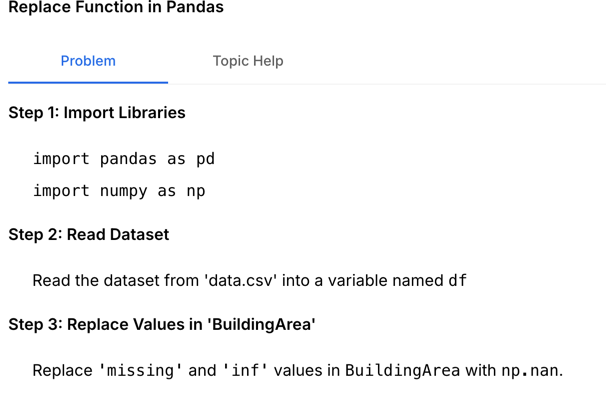

In [3]:
df = pd.read_csv('/Users/mohanrajsubramaniam/PycharmProjects/python_learning/Pandas/datafiles/Melbourne_Housing.csv')
df.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
0,Airport West,3,t,Nelson,03-09-2016,13.5,3042.0,3.0,2.0,1.0,303.0,225,2016.0,Western Metropolitan,3464,840000
1,Albert Park,2,h,hockingstuart,03-09-2016,3.3,3206.0,2.0,1.0,0.0,120.0,82,1900.0,Southern Metropolitan,3280,1275000
2,Albert Park,2,h,Thomson,03-09-2016,3.3,3206.0,2.0,1.0,0.0,159.0,inf,NaN,Southern Metropolitan,3280,1455000
3,Alphington,4,h,Brace,03-09-2016,6.4,3078.0,3.0,2.0,4.0,853.0,263,1930.0,Northern Metropolitan,2211,2000000
4,Alphington,3,h,Jellis,03-09-2016,6.4,3078.0,3.0,2.0,2.0,208.0,inf,2013.0,Northern Metropolitan,2211,1110000


Replace Missing and Inf values in  BuildingArea with np.nan

In [6]:
df['BuildingArea'] = df['BuildingArea'].replace(['Missing','inf'], np.nan)
df['BuildingArea'] = df['BuildingArea'].replace({'missing':np.nan, 'inf':np.nan})
df.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price
0,Airport West,3,t,Nelson,03-09-2016,13.5,3042.0,3.0,2.0,1.0,303.0,225,2016.0,Western Metropolitan,3464,840000
1,Albert Park,2,h,hockingstuart,03-09-2016,3.3,3206.0,2.0,1.0,0.0,120.0,82,1900.0,Southern Metropolitan,3280,1275000
2,Albert Park,2,h,Thomson,03-09-2016,3.3,3206.0,2.0,1.0,0.0,159.0,NaN,NaN,Southern Metropolitan,3280,1455000
3,Alphington,4,h,Brace,03-09-2016,6.4,3078.0,3.0,2.0,4.0,853.0,263,1930.0,Northern Metropolitan,2211,2000000
4,Alphington,3,h,Jellis,03-09-2016,6.4,3078.0,3.0,2.0,2.0,208.0,NaN,2013.0,Northern Metropolitan,2211,1110000


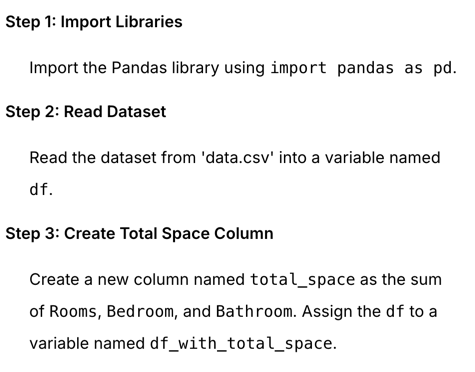

In [9]:
total_space  = df['Rooms'] + df['Bedroom'] + df['Bathroom']
df_with_total_space = df
df_with_total_space['total_space'] = total_space
df_with_total_space.head()

,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,df_with_total_space,total_space
0,Airport West,3,t,Nelson,03-09-2016,13.5,3042.0,3.0,2.0,1.0,303.0,225,2016.0,Western Metropolitan,3464,840000,8.0,8.0
1,Albert Park,2,h,hockingstuart,03-09-2016,3.3,3206.0,2.0,1.0,0.0,120.0,82,1900.0,Southern Metropolitan,3280,1275000,5.0,5.0
2,Albert Park,2,h,Thomson,03-09-2016,3.3,3206.0,2.0,1.0,0.0,159.0,NaN,NaN,Southern Metropolitan,3280,1455000,5.0,5.0
3,Alphington,4,h,Brace,03-09-2016,6.4,3078.0,3.0,2.0,4.0,853.0,263,1930.0,Northern Metropolitan,2211,2000000,9.0,9.0
4,Alphington,3,h,Jellis,03-09-2016,6.4,3078.0,3.0,2.0,2.0,208.0,NaN,2013.0,Northern Metropolitan,2211,1110000,8.0,8.0


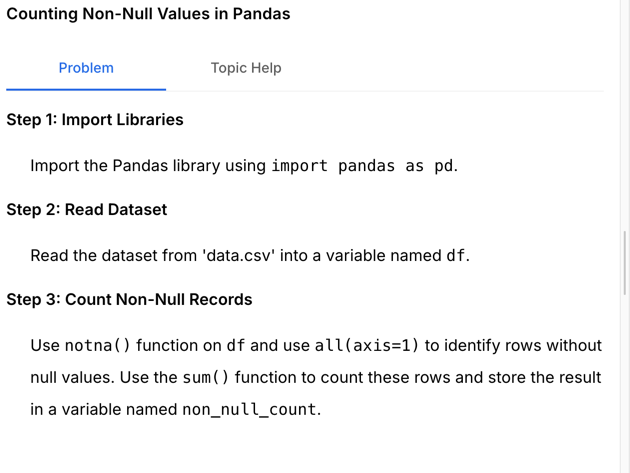

In [10]:
non_null_count = df.notna().all(axis=1).sum()
print(non_null_count)

8814


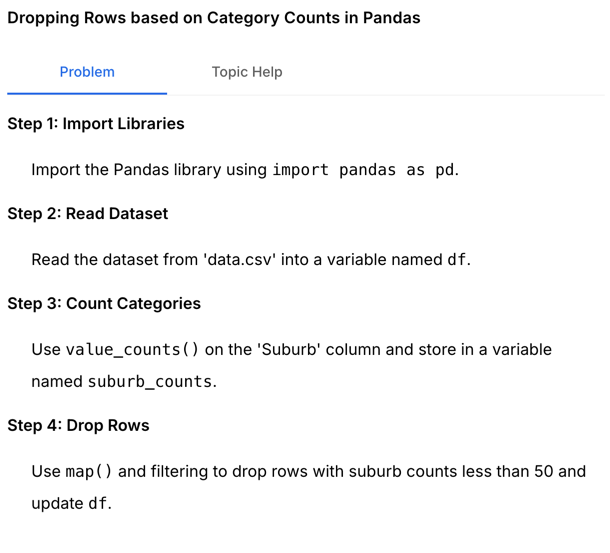

In [13]:
suburb_counts = df['Suburb'].value_counts()
print(suburb_counts)

# Step 4  use map() and filtering to drop rows with suburb counts less than 50 and update df
print(df['Suburb'].map(suburb_counts) >= 50);

df = df[df['Suburb'].map(suburb_counts) >= 50]


0         True
1         True
2         True
3         True
4         True
         ...  
27109     True
27110     True
27111     True
27112    False
27113    False
Name: Suburb, Length: 27114, dtype: bool


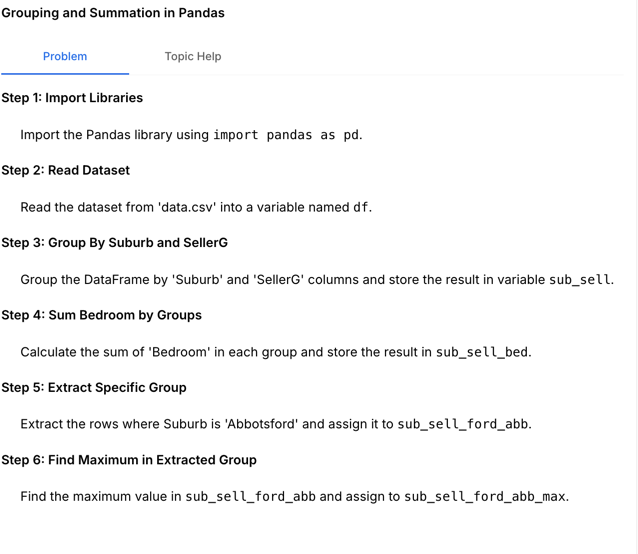

In [16]:
#Step 3 - Group the  dataframe by SubUrb and Seller G
sub_sell = df.groupby(['Suburb','SellerG'])
sub_sell.head()


,Suburb,Rooms,Type,SellerG,Date,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Regionname,Propertycount,Price,df_with_total_space,total_space
0,Airport West,3,t,Nelson,03-09-2016,13.5,3042.0,3.0,2.0,1.0,303.0,225,2016.0,Western Metropolitan,3464,840000,8.0,8.0
1,Albert Park,2,h,hockingstuart,03-09-2016,3.3,3206.0,2.0,1.0,0.0,120.0,82,1900.0,Southern Metropolitan,3280,1275000,5.0,5.0
2,Albert Park,2,h,Thomson,03-09-2016,3.3,3206.0,2.0,1.0,0.0,159.0,NaN,NaN,Southern Metropolitan,3280,1455000,5.0,5.0
3,Alphington,4,h,Brace,03-09-2016,6.4,3078.0,3.0,2.0,4.0,853.0,263,1930.0,Northern Metropolitan,2211,2000000,9.0,9.0
4,Alphington,3,h,Jellis,03-09-2016,6.4,3078.0,3.0,2.0,2.0,208.0,NaN,2013.0,Northern Metropolitan,2211,1110000,8.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27099,Emerald,8,h,iTRAK,30-09-2017,36.9,3782.0,8.0,6.0,4.0,9833.0,NaN,NaN,Eastern Victoria,2259,910000,22.0,22.0
27104,Keysborough,3,h,Area,30-09-2017,25.2,3173.0,3.0,1.0,1.0,539.0,126,1969.0,South-Eastern Metropolitan,8459,771000,7.0,7.0
27105,Kingsbury,2,t,RW,30-09-2017,12.1,3083.0,NaN,NaN,NaN,NaN,NaN,NaN,Northern Metropolitan,1414,512000,NaN,NaN
27108,Narre Warren,4,h,Nicholls,30-09-2017,34.1,3805.0,4.0,3.0,4.0,NaN,NaN,1980.0,South-Eastern Metropolitan,9376,675000,11.0,11.0


In [19]:

sub_sell_bed = sub_sell['Bedroom'].sum()
sub_sell_bed.head()

Suburb      SellerG 
Abbotsford  Beller       3.0
            Biggin      61.0
            Collings     0.0
            Collins      9.0
            Dingle       0.0
Name: Bedroom, dtype: float64

In [23]:
sub_sell_ford_abb = sub_sell_bed.loc['Abbotsford']
sub_sell_ford_abb.head()

SellerG
Beller       3.0
Biggin      61.0
Collings     0.0
Collins      9.0
Dingle       0.0
Name: Bedroom, dtype: float64

In [25]:
sub_sell_ford_abb_max = sub_sell_ford_abb.max()

print(sub_sell_ford_abb_max)

61.0
